In [1]:
import pandas as pd
import zipfile
from scipy.sparse import coo_matrix
import numpy as np

matrix M

In [28]:
def calculte_m(area_distr, eff_population, graph, mobility_rate):
    c = 2e-4
    f =  2 - np.exp(-c*(eff_population / area_distr))

    f_neff = f / eff_population

    #m1 and m2 are 0 if p=1

    m1 = ((1-mobility_rate) **2) * f_neff
    m1 = np.diag(m1) #kronegers thing makes it a diagonal


    #r_ij multipleid by f/neff_j
    term_1 = graph.multiply(f_neff[np.newaxis, :])
    #r_ji (same as transpose term 1)
    term_2 = graph.T.multiply(f_neff[:, np.newaxis])
    m2 = mobility_rate * (1-mobility_rate) * (term_1 + term_2).toarray()

    #ril * nf_neff is same as term 1, then matrix mult with transpose to get m3
    m3= (mobility_rate**2) * (term_1 @ graph.T).toarray()

    return m1 + m2 + m3

calculate threshold

In [29]:
from scipy.linalg import eig


def generate_data(input_graph, input_area_distr, recovery_rate, population, mobility_rate=1, ):
    graph = input_graph
    #visualise_graph(graph)

    #calculat eff population formula 6 from papaer

    eff_population = (1 - mobility_rate) * population + mobility_rate * np.array(graph.T.dot(population)).flatten()
    eff_population[eff_population == 0] = 1

    #devide area acording to log-linear dist

    area_distr = input_area_distr
    area_distr[area_distr == 0] = 1

    matrix_m = calculte_m(area_distr, eff_population, graph, 1)
    matrix_m = matrix_m * population[np.newaxis, :]


    # print("area_distr NaNs:", np.isnan(area_distr).sum(), "zeros:", (area_distr == 0).sum())
    # print("eff_population NaNs:", np.isnan(eff_population).sum())
    # print("population NaNs:", np.isnan(population).sum())
    # print("matrix_m NaNs:", np.isnan(matrix_m).sum(), "Infs:", np.isinf(matrix_m).sum())

    eigenvalues, _ = eig(matrix_m)
    spectral_radius = np.max(np.abs(eigenvalues))

    # -------------------

    # matrix_m_2 = calculte_m(area_distr, eff_population, graph, 0)
    #
    # eigenvalues_2, _ = eigs(matrix_m_2, k=1, which='LM')
    # spectral_radius_2 = np.abs(eigenvalues_2[0])

    # print(spectral_radius)
    # print(spectral_radius_2)

    print(recovery_rate / spectral_radius)
    return recovery_rate / spectral_radius






process data into seperate graphs

In [35]:



def process_data(df_test, counties, id):
    #add land arae data
    df_test['geoid_o'] = df_test['geoid_o'].astype(str)
    df_test['geoid_d'] = df_test['geoid_d'].astype(str)
    counties['GEOID'] = counties['GEOID'].astype(str)

    df_test['geoid_o'] = df_test['geoid_o'].apply(lambda x: x.zfill(5) )
    df_test['geoid_d'] = df_test['geoid_d'].apply(lambda x: x.zfill(5) )
    counties['GEOID'] = counties['GEOID'].apply(lambda x: x.zfill(5) )


    df_merged = df_test.merge(counties[['GEOID', 'area_km2']], left_on='geoid_o', right_on='GEOID', how='left')
    df_merged= df_merged.drop(columns=['lng_o', 'lng_d', 'lat_o', 'lat_d', 'date_range', 'visitor_flows', 'GEOID'])

    #filter georgia
    df_merged = df_merged[df_merged['geoid_o'].str.startswith('13')] # only starting from georgia
    #california
    # df_merged = df_merged[df_merged['geoid_o'].str.startswith('06')]
    # df_merged = df_merged[df_merged['geoid_o'].str.startswith('36')]

    # df_merged = df_merged[~df_merged['geoid_o'].str.startswith(('13121', '13089', '13135', '13067', '12063'), na=False)]

    df_merged = df_merged [df_merged['geoid_d'].isin(df_merged['geoid_o'].unique())]

    #label the nodes
    all_nodes = pd.concat([df_merged['geoid_o'], df_merged['geoid_d']]).unique()
    node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
    number_nodes = len(all_nodes)


    ordered_geoids = [geoid for geoid, idx in sorted(node_to_idx.items(), key=lambda x: x[1])]

    #popoulation
    population = (df_merged.groupby('geoid_o')['pop_flows'].sum() / 7).reset_index()
    population= population.rename(columns= {'pop_flows' : 'total_populaiton'})

    #flows
    df_merged_pop = df_merged.merge(population, on='geoid_o', how='left')
    df_merged_pop['pop_flows'] = df_merged_pop['pop_flows'] / 7

    #area
    area_distr = (df_merged_pop.drop_duplicates('geoid_o')
                    .set_index('geoid_o')['area_km2']
                    .reindex(ordered_geoids)
                    .fillna(0)
                    .values) *  0.386

    #make into graph
    rows = df_merged_pop['geoid_o'].map(node_to_idx).values
    cols = df_merged_pop['geoid_d'].map(node_to_idx).values
    weights = (df_merged_pop['pop_flows'] / df_merged_pop['total_populaiton']).values
    graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))

    #population
    population = (df_merged_pop.drop_duplicates('geoid_o')
                  .set_index('geoid_o')['total_populaiton']
                  .reindex(ordered_geoids)
                  .fillna(0)
                  .astype(float)
                  .values)
    threshold = generate_data(graph, area_distr, 1, population, 1)


    position_array = np.zeros((number_nodes, 2))
    edge_index = torch.tensor(np.vstack((graph.row, graph.col)), dtype=torch.long)

    #save data and threshold
    edge_attr = torch.tensor(graph.data, dtype=torch.float32).view(-1, 1)
    node_features = np.column_stack((population, area_distr, position_array))
    x = torch.tensor(node_features, dtype=torch.float32)
    y = torch.tensor([threshold], dtype=torch.float32)

    data_obj = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    data_obj.graph_id = id

    return data_obj





In [31]:

import torch
from torch_geometric.data import Data
import numpy as np
import os






load census data

In [32]:
import geopandas as gpd

# Census TIGER county boundaries, directly from the US Census Bureau
url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_500k.zip"
counties = gpd.read_file(url)

counties = counties.to_crs(epsg=6933)
counties['area_km2'] = counties.geometry.area / 1e6


area = counties[['GEOID', 'area_km2']]

process each graph

In [37]:
zip_file_path = "datasets/real data/county2county2019.zip"
pyg_graphs = []

with zipfile.ZipFile(zip_file_path, 'r') as z:
    # Loop through every file inside the zip
    i=0
    for filename in z.namelist():

        if not filename.endswith('.csv') or '__MACOSX' in filename or filename.split('/')[-1].startswith('._'):
            continue

        # Open and process the CSV
        with z.open(filename) as f:
            # Load into memory temporarily
            df = pd.read_csv(f)

            clean_name = filename.replace(".csv", "")

            # 2. Split the string by underscores
            parts = clean_name.split("_")
            print(parts)
            # Outputs: ['weekly', 'county2county', '2019', '02', '11']

            date_tracker = "-".join(parts[-3:])

            if (date_tracker == "2019-02-11"):


                graph = process_data(df_test = df, counties = counties, id = date_tracker)
                pyg_graphs.append(graph)

            print(f"proccesed {i} graph")
        i +=1


save_path = 'datasets/version1/...pt'

torch.save(pyg_graphs, save_path)

            # Memory management: processed_df will be overwritten
            # on the next iteration, freeing up RAM.

['county2county2019/weekly', 'county2county', '2019', '09', '23']
proccesed 0 graph
['county2county2019/weekly', 'county2county', '2019', '05', '20']
proccesed 1 graph
['county2county2019/weekly', 'county2county', '2019', '09', '09']
proccesed 2 graph
['county2county2019/weekly', 'county2county', '2019', '10', '14']
proccesed 3 graph
['county2county2019/weekly', 'county2county', '2019', '10', '28']
proccesed 4 graph
['county2county2019/weekly', 'county2county', '2019', '07', '08']
proccesed 5 graph
['county2county2019/weekly', 'county2county', '2019', '02', '04']
proccesed 6 graph
['county2county2019/weekly', 'county2county', '2019', '02', '11']
0.8027179082470467
proccesed 7 graph
['county2county2019/weekly', 'county2county', '2019', '09', '30']
proccesed 8 graph
['county2county2019/weekly', 'county2county', '2019', '10', '07']
proccesed 9 graph
['county2county2019/weekly', 'county2county', '2019', '12', '16']
proccesed 10 graph
['county2county2019/weekly', 'county2county', '2019', '1

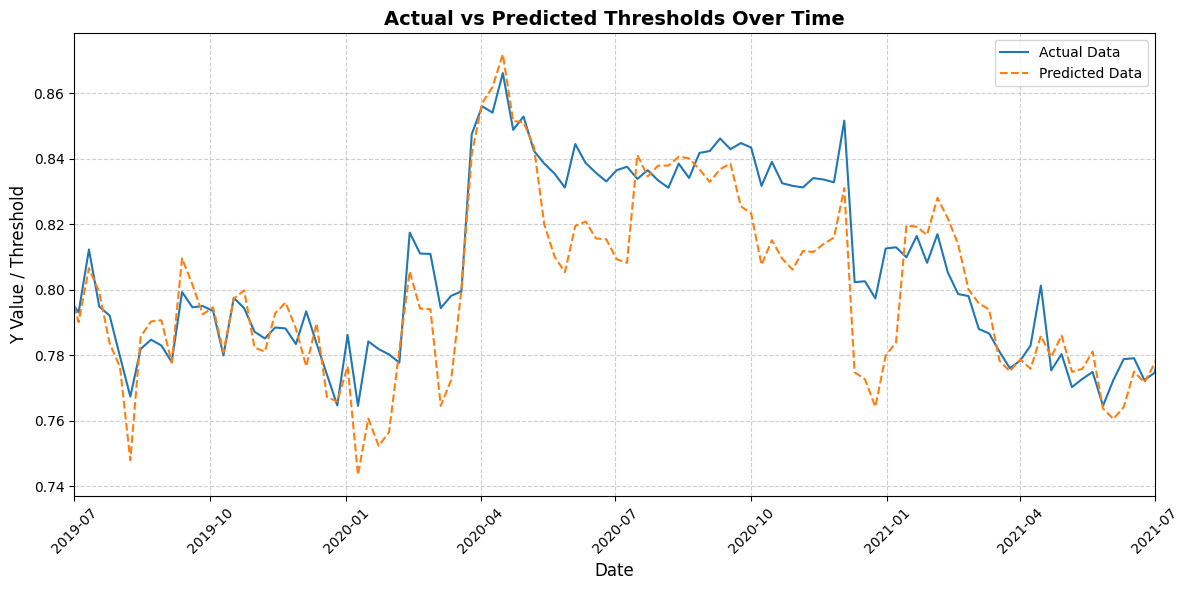

In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime, timedelta

#load data
g2019 = torch.load("/datasets/version1/georgia_all_2019.pt", weights_only=False)
g2020 = torch.load("/datasets/version1/georgia_all_covid.pt", weights_only=False)
g2021 = torch.load("/datasets/version1/georgia_all_2021.pt", weights_only=False)

predictions = torch.load("/datasets/version1/georgia_with_predictionsmod3.pt", weights_only=False)
all_actuals = g2019 + g2020 + g2021


date_pattern = r"(\d{4})[\-_](\d{2})[\-_](\d{2})"

data = []

for actual_obj, pred_obj in zip(all_actuals, predictions):
    #get actual y
    y_act = actual_obj.y.item() if hasattr(actual_obj.y, "item") else actual_obj.y

    #pred y
    y_pred = pred_obj.y_prediction.item() if hasattr(pred_obj.y_prediction, "item") else pred_obj.y_prediction

    # 3. Append them as a SINGLE dictionary (This prevents the NaN holes!)
    data.append({
        "date": clean_date,
        "y_value": y_act,
        "y_pred_value": y_pred
    })

df_plot = pd.DataFrame(data)
df_plot['date'] = pd.to_datetime(df_plot['date'])
df_plot = df_plot.sort_values('date').reset_index(drop=True)

#PLotting
plt.figure(figsize=(12, 6))


plt.plot(df_plot['date'], df_plot['y_value'], label='Actual Data', color='tab:blue', markersize=4)
plt.plot(df_plot['date'], df_plot['y_pred_value'], label='Predicted Data', color='tab:orange', linestyle='--', markersize=4)


# target_date = pd.to_datetime('2020-03-02')
# plt.axvline(x=target_date, color='red', linestyle='--', linewidth=1.5, label='Policy Change End')

# target_date = pd.to_datetime('2020-03-23')
# plt.axvline(x=target_date, color='blue', linestyle='--', linewidth=1.5, label='Policy Change End')

# target_date = pd.to_datetime('2020-04-03')
# plt.axvline(x=target_date, color='red', linestyle='--', linewidth=1.5, label='Policy Change End')

# target_date = pd.to_datetime('2020-04-24')
# plt.axvline(x=target_date, color='green', linestyle='--', linewidth=1.5, label='Policy Change End')
#
# target_date = pd.to_datetime('2020-07-10')
# plt.axvline(x=target_date, color='red', linestyle='--', linewidth=1.5, label='Policy Change End')
#
# target_date = pd.to_datetime('2020-09-11')
# plt.axvline(x=target_date, color='green', linestyle='--', linewidth=1.5, label='Policy Change End')
#
# target_date = pd.to_datetime('2020-12-06')
# plt.axvline(x=target_date, color='red', linestyle='--', linewidth=1.5, label='Policy Change End')
#
# # target_date = pd.to_datetime('2020-05-27')
# # plt.axvline(x=target_date, color='orange', linestyle='--', linewidth=1.5, label='Policy Change End')
#
# target_date = pd.to_datetime('2021-11-25')
# plt.axvline(x=target_date, color='red', linestyle='--', linewidth=1.5, label='Policy Change End')
#
# target_date = pd.to_datetime('2021-09-01')
# plt.axvline(x=target_date, color='red', linestyle='--', linewidth=1.5, label='Policy Change End')

# target_date = pd.to_datetime('2020-02-02')
# plt.axvline(x=target_date, color='orange', linestyle='--', linewidth=1.5, label='Policy Change End')



# Formatting
# plt.ylim(0.69, 0.94)
start_date = pd.to_datetime('2019-07-01')
end_date = pd.to_datetime('2021-07-01')
plt.xlim(start_date, end_date)
plt.title("Actual vs Predicted Thresholds Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Y Value / Threshold", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()

plt.show()

download NYT data

In [3]:
print("Downloading NYT COVID-19 County Data...")
url = "https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-counties.csv"
df_covid = pd.read_csv(url)

Plot predictiona and case counts

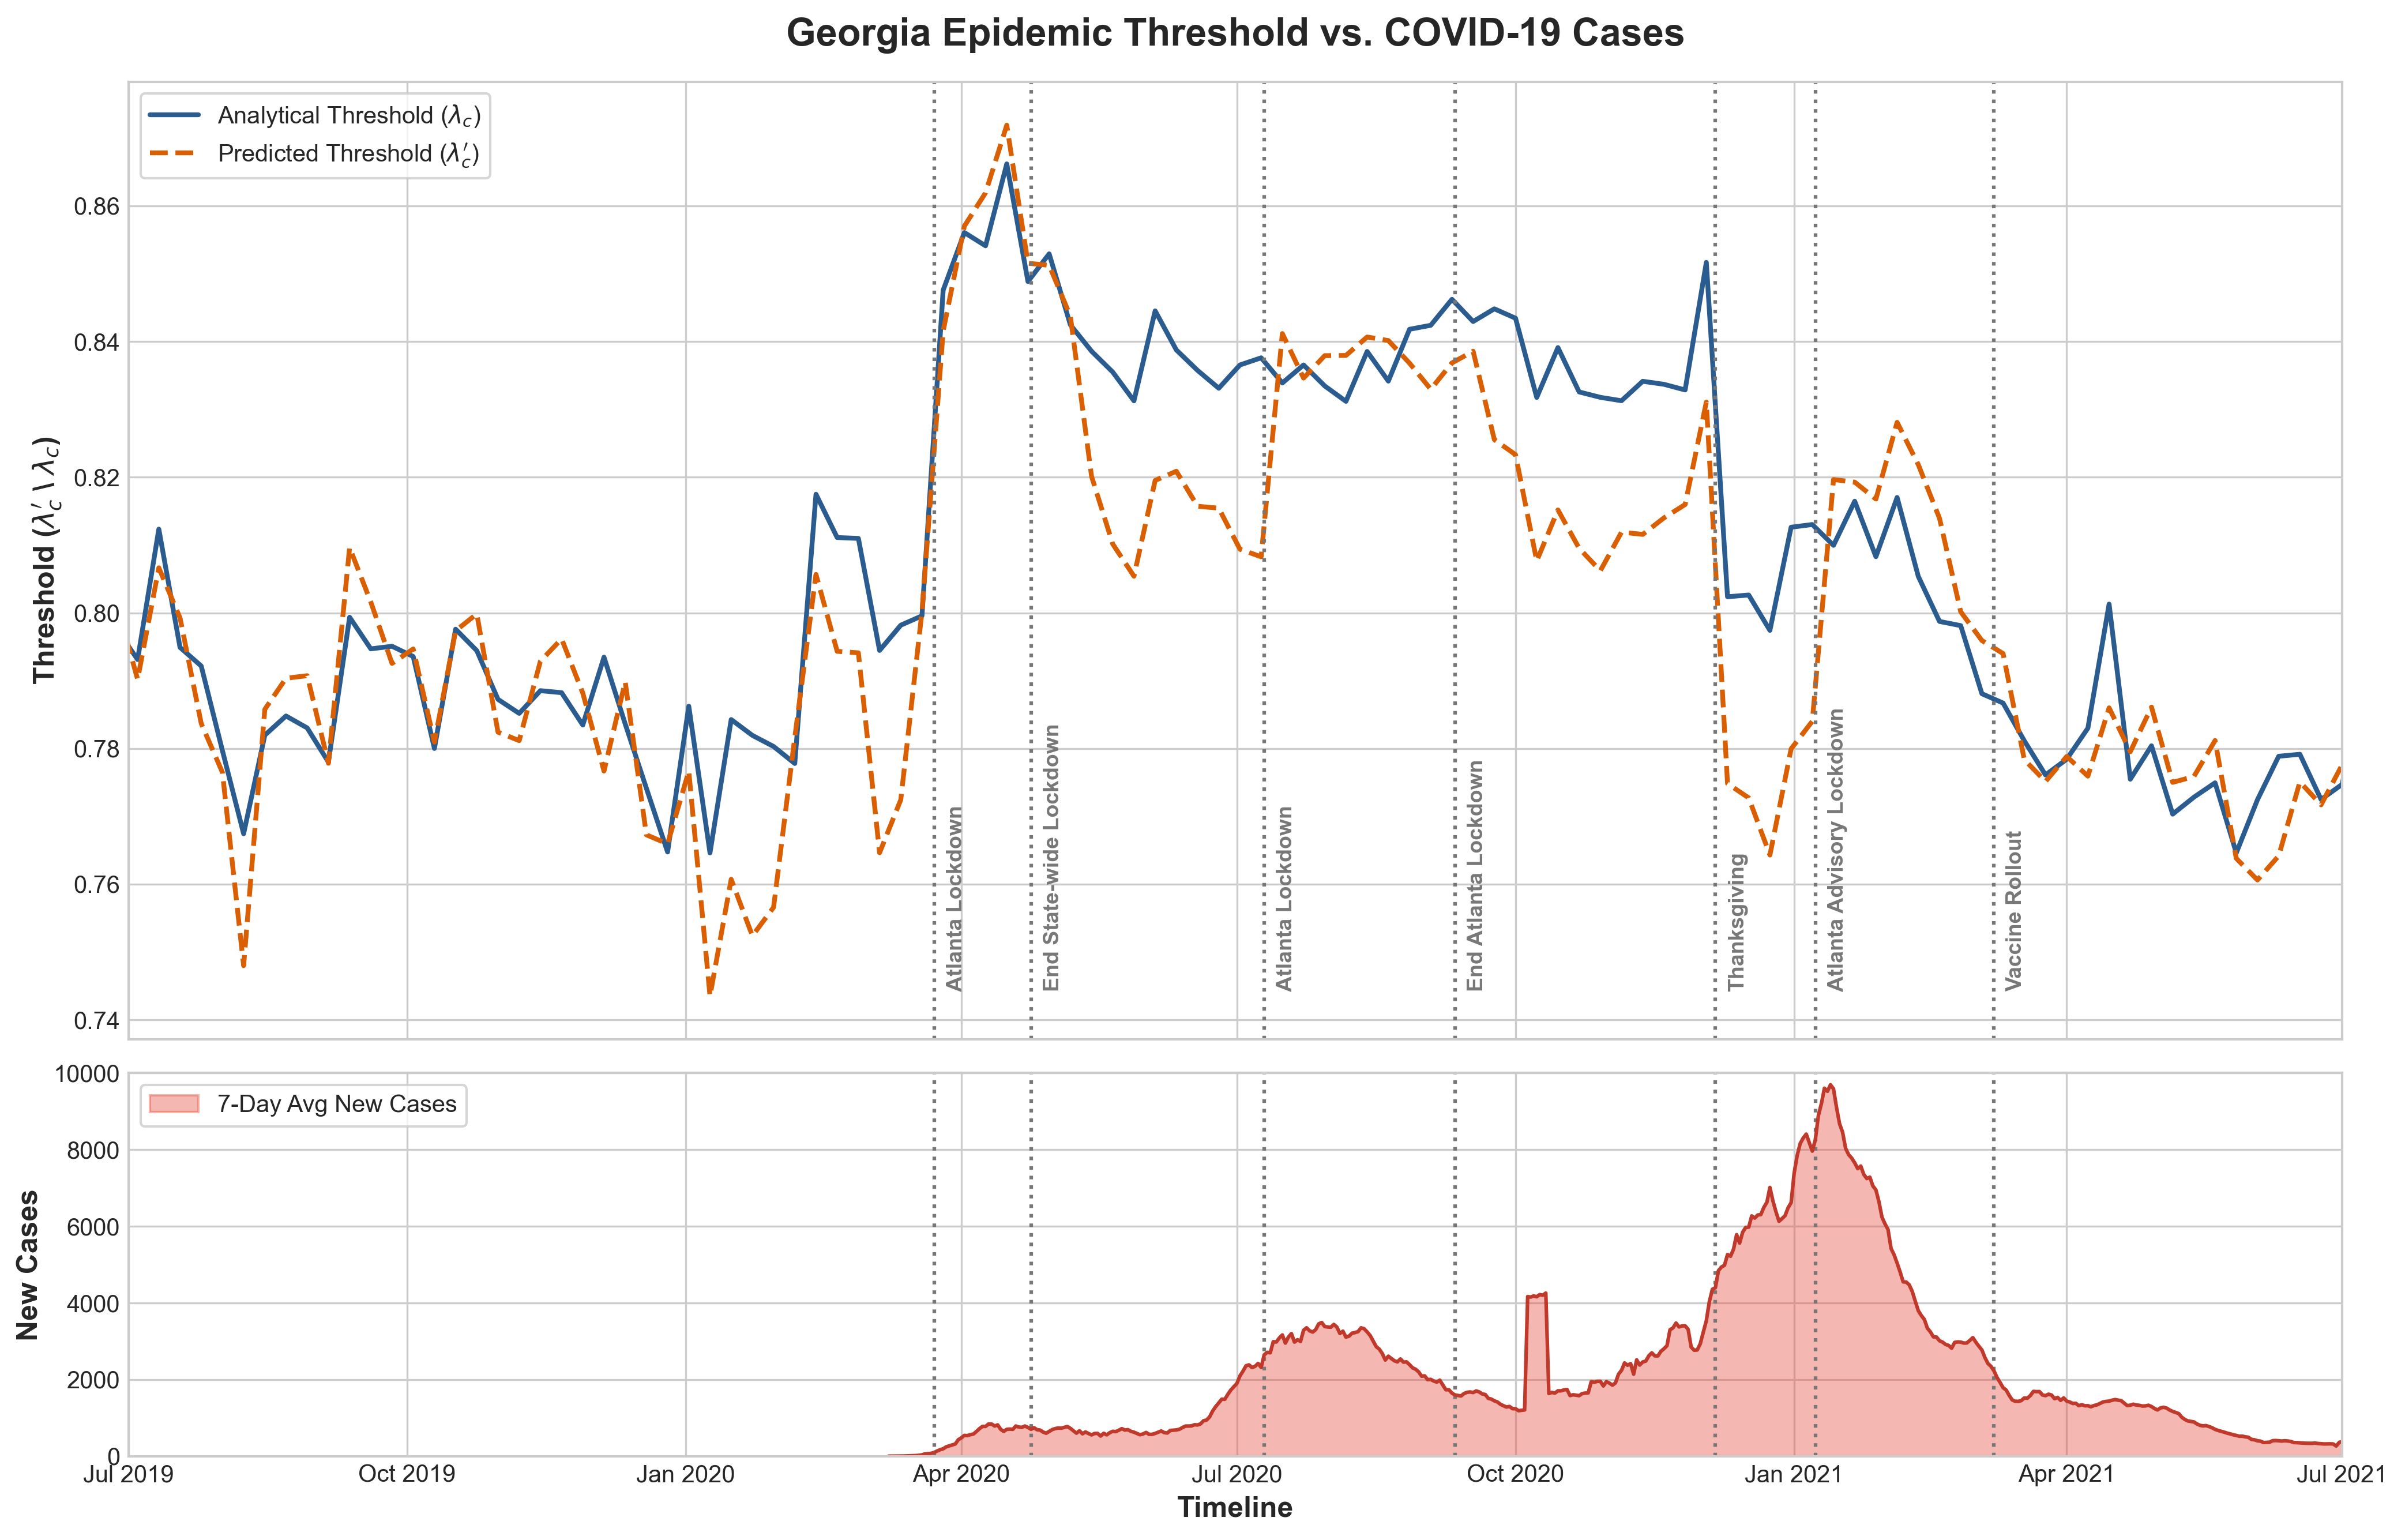

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates



# Filter for Atlanta's core counties (Fulton and DeKalb) in Georgia
df_atl = df_covid[(df_covid['state'] == 'Georgia')].copy()

# & (df_covid['county'].isin(['Fulton', 'DeKalb', 'Gwinnett','Cobb', 'Clayton']))

# NYT data is cumulative. We need to group by date, sum both counties, and get daily NEW cases.
df_atl = df_atl.groupby('date')['cases'].sum().reset_index()
df_atl['date'] = pd.to_datetime(df_atl['date'])
df_atl = df_atl.sort_values('date')

# Calculate daily new cases by subtracting yesterday's total from today's
df_atl['new_cases'] = df_atl['cases'].diff().fillna(0)
# Negative values can occasionally happen due to state reporting corrections; clamp to 0
df_atl['new_cases'] = df_atl['new_cases'].clip(lower=0)

# Smooth the cases with a 7-day rolling average (makes the graph look much cleaner, like your reference image)
df_atl['smoothed_cases'] = df_atl['new_cases'].rolling(window=7).mean()


# --- 2. Create the Stacked Layout ---
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure with 2 subplots (ax1 = Thresholds, ax2 = Cases)
# sharex=True locks the timelines together so they align perfectly
# height_ratios=[2.5, 1] makes the top graph 2.5x taller than the bottom graph
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), dpi=300, sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})

# ==========================================
# TOP PLOT (ax1): Your Threshold Data
# ==========================================
ax1.plot(df_plot['date'], df_plot['y_value'], label='Analytical Threshold ($\lambda_c$)', color='#2b5c8f', linewidth=2)
ax1.plot(df_plot['date'], df_plot['y_pred_value'], label='Predicted Threshold ($\lambda_c^\prime$)', color='#d95f02', linestyle='--', linewidth=2)

ax1.set_title("Georgia Epidemic Threshold vs. COVID-19 Cases", fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel("Threshold ($\lambda_c^\prime$ \ $\lambda_c$)", fontsize=12, fontweight='semibold')
ax1.legend(loc='upper left', frameon=True)


milestones = [
    ('2020-03-23', 'Atlanta Lockdown', '#777777'),
    ('2020-04-24', 'End State-wide Lockdown', '#777777'),
    ('2020-07-10', 'Atlanta Lockdown', '#777777'),
    ('2020-09-11', 'End Atlanta Lockdown', '#777777'),
    ('2020-11-21', 'Thanksgiving', '#777777'),
    ('2021-03-08', 'Vaccine Rollout', '#777777'),
    ('2021-01-08', 'Atlanta Advisory Lockdown', '#777777'),
]

# ('2021-11-25', 'Omicron News', '#777777'),
for date_str, label, color in milestones:
    t_date = pd.to_datetime(date_str)

    # 1. This loops through both ax1 and ax2 to draw the vertical line on both!
    for ax in [ax1, ax2]:
        ax.axvline(x=t_date, color=color, linestyle=':', linewidth=1.5, alpha=1, zorder=2)

    # 2. Keep the text label only on the TOP plot so it doesn't get cluttered
    ax1.text(t_date + pd.Timedelta(days=4),
             ax1.get_ylim()[0] + (ax1.get_ylim()[1] - ax1.get_ylim()[0]) * 0.05,
             label, rotation=90, verticalalignment='bottom', fontsize=9,
             color=color, fontweight='semibold', zorder=4)
# ==========================================
# BOTTOM PLOT (ax2): Atlanta COVID Cases
# ==========================================
# We use a filled area plot for the cases to match standard epidemiological graphs
ax2.fill_between(df_atl['date'], 0, df_atl['smoothed_cases'], color='#e74c3c', alpha=0.4, label='7-Day Avg New Cases')
ax2.plot(df_atl['date'], df_atl['smoothed_cases'], color='#c0392b', linewidth=1.5)

ax2.set_ylabel("New Cases", fontsize=12, fontweight='semibold')
ax2.set_xlabel("Timeline", fontsize=12, fontweight='semibold')
ax2.legend(loc='upper left', frameon=True)

# Align the x-axis limits so both graphs start and end at the exact same time
start_date = pd.to_datetime('2019-07-01') # Start right before the pandemic
end_date = pd.to_datetime('2021-07-01')
ax1.set_xlim(start_date, end_date)

# Clean up the dates on the x-axis
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0, ha='center', fontsize=10)
ax2.set_ylim(0, 10000)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05) # Squeezes the two graphs closer together
plt.show()